# Figure 4 Reproduction

This notebook reproduces Figure 4 from the paper using pre-processed CSV data.

The figure shows four types of analyses across three datasets:
- **Row 1**: Subject ablation (performance vs. number of pretraining subjects).
- **Row 2**: Trial ablation (performance vs. number of finetuning trials).
- **Row 3**: Iso-ablation (performance trade-off between subjects and trials for a fixed data budget).
- **Row 4**: Data efficiency (ratio of data needed for a finetuned vs. zero-shot model to reach the same performance).

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import string
from pathlib import Path
from matplotlib.gridspec import GridSpec
import matplotlib.ticker
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import re

# --- Configuration ---
MODEL_COLORS = {
    "EEGNetv4": "#f4a582",
    "ATCNet": "#92c5de",
    "ShallowConvNet": "#ca0020",
    "DeepConvNet": "#0571b0",
}

DATASET_INFO = {
    "Yang2025": {"name_for_plot": "MI (Yang2025)"},
    "BI2015a": {"name_for_plot": "P300 (BI2015a)"},
    "Lee2019_SSVEP": {"name_for_plot": "SSVEP (Lee2019)"},
}
PREFERRED_DATASET_ORDER = ["Yang2025", "BI2015a", "Lee2019_SSVEP"]

GLOBAL_FONTSIZE = 7

# --- Apply Global Matplotlib Styles (from original script's fallback) ---
mpl.rcParams.update(
    {
        "font.size": GLOBAL_FONTSIZE,
        "legend.fontsize": GLOBAL_FONTSIZE,
        "axes.titlesize": GLOBAL_FONTSIZE,
        "axes.labelsize": GLOBAL_FONTSIZE,
        "xtick.labelsize": GLOBAL_FONTSIZE,
        "ytick.labelsize": GLOBAL_FONTSIZE,
        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "savefig.format": "pdf",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


In [2]:
# --- Load Data ---
data_dir = Path("figure_data")
subject_df, trial_df, iso_df, efficiency_df = (pd.DataFrame() for _ in range(4))

try:
    subject_df = pd.read_csv(data_dir / "fig4_subject_ablation_data.csv")
    trial_df = pd.read_csv(data_dir / "fig4_trial_ablation_data.csv")
    iso_df = pd.read_csv(data_dir / "fig4_iso_ablation_data.csv")
    efficiency_df = pd.read_csv(data_dir / "fig4_efficiency_data.csv")
    print("All data files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please ensure you have run the `create_fig4_data.py` script first.")

print(f"\nSubject ablation data shape: {subject_df.shape}")
print(f"Trial ablation data shape: {trial_df.shape}")
print(f"Iso-ablation data shape: {iso_df.shape}")
print(f"Efficiency data shape: {efficiency_df.shape}")

All data files loaded successfully.

Subject ablation data shape: (184, 5)
Trial ablation data shape: (144, 5)
Iso-ablation data shape: (187, 7)
Efficiency data shape: (310, 8)


In [3]:
# --- Plotting Functions (Updated for visual consistency) ---


def plot_subject_ablation(ax, df, is_first_col, title):
    if df.empty:
        return ax.text(0.5, 0.5, "No Data", ha="center", va="center", color="grey")
    unique_nps = sorted(df["num_pretrain_subjects"].unique())
    x_map = {nps: i for i, nps in enumerate(unique_nps)}
    for model_name, model_group in df.groupby("model"):
        model_group = model_group.sort_values("num_pretrain_subjects")
        x_coords = model_group["num_pretrain_subjects"].map(x_map)
        ax.plot(
            x_coords,
            model_group["mean_accuracy"],
            marker="o",
            linestyle="-",
            color=MODEL_COLORS.get(model_name),
            markersize=3,
            linewidth=1,
        )
        ax.errorbar(
            x_coords,
            model_group["mean_accuracy"],
            yerr=model_group["sem_accuracy"],
            fmt="none",
            color=MODEL_COLORS.get(model_name),
            capsize=2,
            elinewidth=0.8,
        )
    ax.set_title(title, fontsize=GLOBAL_FONTSIZE, pad=12, fontweight="bold")
    if is_first_col:
        ax.set_ylabel(
            "Subject ablation\nMean bal. acc. (±SEM)",
            fontsize=GLOBAL_FONTSIZE,
            fontweight="bold",
        )
    ax.set_xlabel("Number of pretraining subjects", fontsize=GLOBAL_FONTSIZE)
    tick_indices = np.linspace(
        0, len(unique_nps) - 1, min(8, len(unique_nps)), dtype=int
    )
    ax.set_xticks([x_map[unique_nps[i]] for i in tick_indices])
    ax.set_xticklabels([unique_nps[i] for i in tick_indices], rotation=45, ha="right")
    ax.set_xlim(min(x_map.values()) - 0.5, max(x_map.values()) + 0.5)
    ax.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4))
    ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:0.2f}"))


def plot_trial_ablation(ax, df, is_first_col):
    if df.empty:
        return ax.text(0.5, 0.5, "No Data", ha="center", va="center", color="grey")
    unique_nt = sorted(df["num_trials"].unique())
    x_map = {nt: i for i, nt in enumerate(unique_nt)}
    for model_name, model_group in df.groupby("model"):
        model_group = model_group.sort_values("num_trials")
        x_coords = model_group["num_trials"].map(x_map)
        ax.plot(
            x_coords,
            model_group["mean_accuracy"],
            marker="o",
            linestyle="-",
            color=MODEL_COLORS.get(model_name),
            markersize=3,
            linewidth=1,
        )
        ax.errorbar(
            x_coords,
            model_group["mean_accuracy"],
            yerr=model_group["sem_accuracy"],
            fmt="none",
            color=MODEL_COLORS.get(model_name),
            capsize=2,
            elinewidth=0.8,
        )
    if is_first_col:
        ax.set_ylabel(
            "Trial ablation\nMean bal. acc. (±SEM)",
            fontsize=GLOBAL_FONTSIZE,
            fontweight="bold",
        )
    ax.set_xlabel("Number of training trials", fontsize=GLOBAL_FONTSIZE)
    tick_indices = np.linspace(0, len(unique_nt) - 1, min(5, len(unique_nt)), dtype=int)
    ax.set_xticks([x_map[unique_nt[i]] for i in tick_indices])
    ax.set_xticklabels([unique_nt[i] for i in tick_indices], rotation=45, ha="right")
    ax.set_xlim(min(x_map.values()) - 0.5, max(x_map.values()) + 0.5)
    ax.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4))
    ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:0.2f}"))


def plot_iso_ablation(ax, df, is_first_col):
    if df.empty:
        return ax.text(0.5, 0.5, "No Data", ha="center", va="center", color="grey")
    df["x_label"] = df["budget"] + "_" + df["num_pretrain_subjects"].astype(str)
    low_labels = sorted(
        df[df["budget"] == "Low"]["x_label"].unique(),
        key=lambda x: int(x.split("_")[1]),
    )
    high_labels = sorted(
        df[df["budget"] == "High"]["x_label"].unique(),
        key=lambda x: int(x.split("_")[1]),
    )
    x_labels_sorted = low_labels + high_labels
    if not x_labels_sorted:
        return ax.text(0.5, 0.5, "No Data", ha="center", va="center", color="grey")
    x_map = {label: i for i, label in enumerate(x_labels_sorted)}
    df["x_pos"] = df["x_label"].map(x_map)
    for model_name, model_group in df.groupby("model"):
        for budget_type in ["Low", "High"]:
            budget_data = model_group[model_group["budget"] == budget_type].sort_values(
                "x_pos"
            )
            if not budget_data.empty:
                ax.plot(
                    budget_data["x_pos"],
                    budget_data["mean_accuracy"],
                    marker="o",
                    color=MODEL_COLORS.get(model_name),
                    markersize=3,
                    linewidth=1,
                )
                ax.errorbar(
                    budget_data["x_pos"],
                    budget_data["mean_accuracy"],
                    yerr=budget_data["sem_accuracy"],
                    fmt="none",
                    color=MODEL_COLORS.get(model_name),
                    capsize=2,
                    elinewidth=0.8,
                )
    if is_first_col:
        ax.set_ylabel(
            "Iso-ablation\nMean bal. acc. (±SEM)",
            fontsize=GLOBAL_FONTSIZE,
            fontweight="bold",
        )
    ax.set_xlabel("Number of pretraining subjects", fontsize=GLOBAL_FONTSIZE)
    num_low = len(low_labels)
    if num_low > 0 and num_low < len(x_labels_sorted):
        ax.axvline(x=num_low - 0.5, color="grey", linestyle="--", linewidth=1)
        ax.text(
            (num_low - 1) / 2,
            1.0,
            "Low budget",
            ha="center",
            va="bottom",
            fontsize=GLOBAL_FONTSIZE - 1,
            transform=ax.get_xaxis_transform(),
        )
        ax.text(
            num_low + (len(high_labels) - 1) / 2,
            1.0,
            "High budget",
            ha="center",
            va="bottom",
            fontsize=GLOBAL_FONTSIZE - 1,
            transform=ax.get_xaxis_transform(),
        )
    subject_counts = [re.search(r"\d+$", label).group(0) for label in x_labels_sorted]
    tick_indices = np.linspace(0, len(x_map) - 1, min(6, len(x_map)), dtype=int)
    ax.set_xticks([list(x_map.values())[i] for i in tick_indices])
    ax.set_xticklabels(
        [subject_counts[i] for i in tick_indices], rotation=45, ha="right"
    )
    ax.set_xlim(-0.5, len(x_labels_sorted) - 0.5)
    ax.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4))
    ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:0.2f}"))


def plot_efficiency(ax_top, ax_bottom, df, is_first_col):
    if df.empty:
        return ax_top.text(0.5, 0.5, "No Data", ha="center", va="center", color="grey")
    df_matched, df_unmatched = (
        df[df["status"] == "matched"],
        df[df["status"] == "unmatched_cft_is_better"],
    )
    for model_name, model_group in df_matched.groupby("model"):
        color = MODEL_COLORS.get(model_name)
        ax_top.scatter(
            model_group[model_group["scaling_type"] == "subject"][
                "finetuned_balanced_accuracy"
            ],
            model_group[model_group["scaling_type"] == "subject"]["efficiency_ratio"],
            c=color,
            marker="o",
            s=15,
            alpha=0.8,
            edgecolors="w",
            linewidth=0.5,
        )
        ax_top.scatter(
            model_group[model_group["scaling_type"] == "trial"][
                "finetuned_balanced_accuracy"
            ],
            model_group[model_group["scaling_type"] == "trial"]["efficiency_ratio"],
            c=color,
            marker="P",
            s=20,
            alpha=0.8,
            edgecolors="w",
            linewidth=0.5,
        )
    for model_name, model_group in df_unmatched.groupby("model"):
        color = MODEL_COLORS.get(model_name)
        ax_bottom.scatter(
            model_group[model_group["scaling_type"] == "subject"][
                "finetuned_balanced_accuracy"
            ],
            [0.5] * len(model_group[model_group["scaling_type"] == "subject"]),
            c=color,
            marker="o",
            s=15,
            alpha=0.7,
            edgecolors="w",
            linewidth=0.5,
        )
        ax_bottom.scatter(
            model_group[model_group["scaling_type"] == "trial"][
                "finetuned_balanced_accuracy"
            ],
            [0.5] * len(model_group[model_group["scaling_type"] == "trial"]),
            c=color,
            marker="P",
            s=20,
            alpha=0.7,
            edgecolors="w",
            linewidth=0.5,
        )
    all_ratios, all_perfs = (
        df_matched["efficiency_ratio"].dropna(),
        df["finetuned_balanced_accuracy"].dropna(),
    )
    ax_top.set_yscale("log", base=2)
    ax_top.axhline(y=1.0, color="black", linestyle="--", linewidth=1.2)
    if not all_ratios.empty:
        ymin, ymax = max(0.01, all_ratios.min() * 0.8), all_ratios.max() * 1.2
        ax_top.set_ylim(ymin, ymax)
        ax_top.yaxis.set_major_locator(matplotlib.ticker.LogLocator(base=2, numticks=3))
        ax_top.axhspan(ymin, 1.0, facecolor="#2ca02c", alpha=0.1, zorder=-100)
        ax_top.axhspan(1.0, ymax, facecolor="#d62728", alpha=0.1, zorder=-100)
    ax_top.spines["bottom"].set_visible(False)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_top.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.1f}x"))
    if is_first_col:
        ax_top.set_ylabel(
            "Efficiency ratio\n(CFT / ZS)",
            fontsize=GLOBAL_FONTSIZE,
            fontweight="bold",
            labelpad=0,
        )
    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.set_ylim(0, 1)
    ax_bottom.set_yticks([])
    ax_bottom.set_xlabel("Finetuned bal. acc.", fontsize=GLOBAL_FONTSIZE)
    ax_bottom.axhspan(0, 1, facecolor="darkgreen", alpha=0.25, zorder=-100)
    ax_bottom.set_ylabel(
        "1/$\infty$", fontsize=GLOBAL_FONTSIZE, rotation=0, labelpad=10, va="center"
    )
    if not all_perfs.empty:
        ax_bottom.set_xlim(
            max(0, all_perfs.min() - 0.02), min(1, all_perfs.max() + 0.02)
        )
    ax_bottom.xaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4))
    ax_bottom.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.2f}"))
    d = 0.015
    kwargs = dict(color="k", clip_on=False, lw=1)
    ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, **kwargs)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), transform=ax_bottom.transAxes, **kwargs)

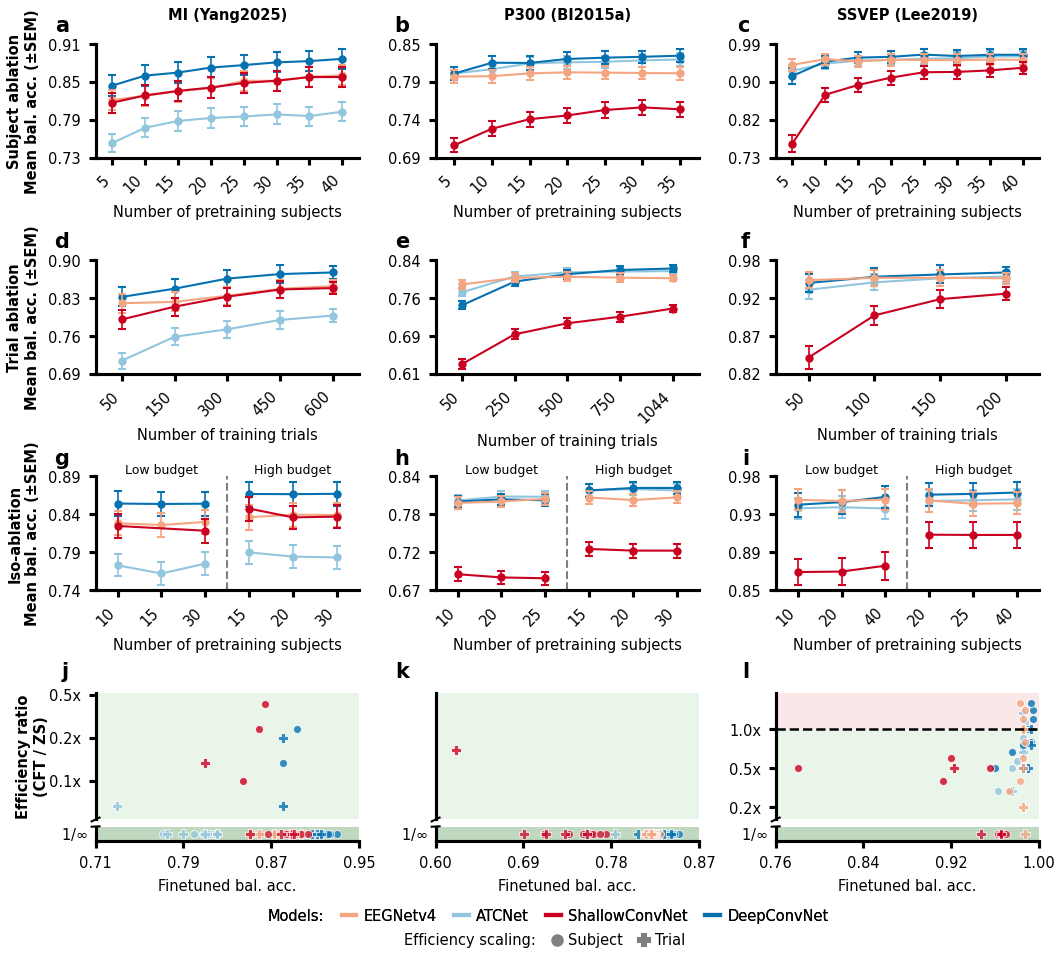

In [4]:
# --- Figure Creation and Layout (from fig4.py) ---

# Define layout parameters
num_rows, num_cols = 4, 3
total_w_cm = 18.0
margin_l_cm, margin_r_cm = 1.525, 0.5
margin_t_cm, margin_b_cm = 0.8, 2.2
spacing_h_cm, spacing_v_cm = 1.3, 1.0

# Calculate panel and figure dimensions in inches
eff_w_cm = total_w_cm - margin_l_cm - margin_r_cm
panel_w_cm = (eff_w_cm - (num_cols - 1) * spacing_h_cm) / num_cols
panel_h_cm = panel_w_cm / 1.7  # Maintain aspect ratio
eff_h_cm = num_rows * panel_h_cm + (num_rows - 1) * spacing_v_cm
total_h_cm = eff_h_cm + margin_t_cm + margin_b_cm
fig = plt.figure(figsize=(total_w_cm / 2.54, total_h_cm / 2.54))

# Main GridSpec
gs_outer = GridSpec(num_rows, num_cols, figure=fig, height_ratios=[1, 1, 1, 1.3])
panel_labels = list(string.ascii_lowercase)
main_axes = [[None] * num_cols for _ in range(num_rows)]

# --- Main plotting loop ---
for col_idx, dataset_key in enumerate(PREFERRED_DATASET_ORDER):
    is_first_col = col_idx == 0
    dataset_name = DATASET_INFO.get(dataset_key, {}).get("name_for_plot", dataset_key)
    # Row 1: Subject Ablation
    ax0 = fig.add_subplot(gs_outer[0, col_idx])
    main_axes[0][col_idx] = ax0
    plot_subject_ablation(
        ax0,
        subject_df[subject_df["dataset"] == dataset_key],
        is_first_col,
        dataset_name,
    )
    # Row 2: Trial Ablation
    ax1 = fig.add_subplot(gs_outer[1, col_idx])
    main_axes[1][col_idx] = ax1
    plot_trial_ablation(ax1, trial_df[trial_df["dataset"] == dataset_key], is_first_col)
    # Row 3: Iso Ablation
    ax2 = fig.add_subplot(gs_outer[2, col_idx])
    main_axes[2][col_idx] = ax2
    plot_iso_ablation(ax2, iso_df[iso_df["dataset"] == dataset_key], is_first_col)
    # Row 4: Efficiency (Broken Axis)
    gs_inner = gs_outer[3, col_idx].subgridspec(
        2, 1, hspace=0.1, height_ratios=[0.9, 0.1]
    )
    ax_top = fig.add_subplot(gs_inner[0])
    ax_bottom = fig.add_subplot(gs_inner[1], sharex=ax_top)
    main_axes[3][col_idx] = ax_top
    plot_efficiency(
        ax_top,
        ax_bottom,
        efficiency_df[efficiency_df["dataset"] == dataset_key],
        is_first_col,
    )

# --- Add Panel Labels (a, b, c, ...) ---
for r, row_axes in enumerate(main_axes):
    for c, ax in enumerate(row_axes):
        if ax:
            ax.text(
                -0.1,
                1.25,
                panel_labels[r * num_cols + c],
                transform=ax.transAxes,
                fontsize=10,
                fontweight="bold",
                va="top",
                ha="right",
            )

# --- Create Legends ---
model_handles = [
    Line2D([0], [0], color=c, label=m, lw=2) for m, c in MODEL_COLORS.items()
]
model_leg = fig.legend(
    handles=[mpatches.Patch(color="none", label="Models:")] + model_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.035),
    ncol=5,
    frameon=False,
    fontsize=GLOBAL_FONTSIZE,
    handletextpad=0.5,
    columnspacing=1.2,
    handlelength=1,
)
symbol_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="grey",
        label="Subject",
        linestyle="None",
        markersize=5,
    ),
    Line2D(
        [0],
        [0],
        marker="P",
        color="grey",
        label="Trial",
        linestyle="None",
        markersize=6,
    ),
]
fig.legend(
    handles=[mpatches.Patch(color="none", label="Efficiency scaling:")]
    + symbol_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
    fontsize=GLOBAL_FONTSIZE,
    handletextpad=0.5,
    columnspacing=1.2,
    handlelength=0.5,
)
fig.add_artist(model_leg)

# --- Final Adjustments & Save (from original script) ---
left_norm = margin_l_cm / total_w_cm
right_norm = 1 - (margin_r_cm / total_w_cm)
bottom_norm = margin_b_cm / total_h_cm
top_norm = 1 - (margin_t_cm / total_h_cm)
wspace_val = spacing_h_cm / panel_w_cm if panel_w_cm > 0 else 0.1
hspace_val = (
    (spacing_v_cm + 1.2) / panel_h_cm if panel_h_cm > 0 else 0.1
)  # Special hspace from original

fig.subplots_adjust(
    left=left_norm,
    right=right_norm,
    bottom=bottom_norm,
    top=top_norm,
    wspace=wspace_val,
    hspace=hspace_val,
)

plt.savefig("figure4.pdf", dpi=300)
plt.show()